# Wide-Swath Altimeter Validation: SWOT

The Surface Water and Ocean Topography ([SWOT](https://swot.jpl.nasa.gov/)) mission maps water surface heights with the Ka-band Radar Interferometer (KaRIn), which images two swaths, each about 50 km wide, on either side of a 20 km gap centered on the ground track (where a conventional nadir altimeter observes). SWOT flies a non-sun-synchronous orbit (77.6 deg inclination, 890.5 km altitude) that repeats its ground track every 20.86 days. KaRIn can be modeled in TAT-C with two `PointedInstrument`s, rolled to the left and right of the ground track. This notebook compares this model with SWOT's sea surface height data over three weeks, from 9 September to 1 October 2026, and asks:

1. **Orbit and repeat cycle.** Does TAT-C's propagation of a public two-line element (TLE) set follow SWOT's ground track over three weeks, and does TAT-C recognize its repeat cycle?
2. **Swath geometry.** Do the rolled instruments observe the two swaths and the gap between them, at the times they are observed?

## Reference Data

The SWOT Level 2 KaRIn Low Rate Sea Surface Height product (Basic, version D) is distributed by the [Physical Oceanography Distributed Active Archive Center](https://podaac.jpl.nasa.gov/SWOT) (PO.DAAC); downloading requires a free [NASA Earthdata Login](https://urs.earthdata.nasa.gov/) account and the `earthaccess` package. Each file covers one half-orbit pass on a grid of 69 pixels, 2 km apart across track (34 on either side of the ground track), with a line every 2 km along track and the time at which each line was observed. The grid is fixed to the pass's reference ground track (it is identical in every cycle), on which SWOT is maintained to within about 1 km. Pixels with good-quality sea surface heights (quality flag 0) show where KaRIn observes over the ocean. One file every two days and the same pass in two consecutive cycles (12 files, about 110 MB) are cached in a local `data/swot` directory.

SWOT is modeled with a TLE from [CelesTrak](https://celestrak.org/) whose epoch (4 October 2026, 14:22 UTC) follows the analysis period by 3 to 25 days.

In [1]:
import concurrent.futures
import re
from datetime import datetime, timedelta, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from pyproj import Geod
from skyfield.api import wgs84

from tatc.analysis import collect_observations
from tatc.constants import EARTH_MEAN_RADIUS, timescale
from tatc.schemas import GeneralPerturbationsOrbit, Point, PointedInstrument, Satellite

DATA_DIR = Path("data") / "swot"
DATA_DIR.mkdir(parents=True, exist_ok=True)
START = datetime(2026, 9, 9, tzinfo=timezone.utc)
END = datetime(2026, 10, 2, tzinfo=timezone.utc)
TLE = [
    "1 54754U 22173A   26277.59902338  .00000094  00000+0  65386-4 0  9997",
    "2 54754  77.6084 247.6064 0000264 143.3265 216.7905 14.00173063194463",
]
TLE_EPOCH = datetime(2026, 10, 4, 14, 22, 35, tzinfo=timezone.utc)
geod = Geod(ellps="WGS84")


def granule_key(name):
    """Cycle, pass, and start time of a granule name."""
    match = re.search(r"_(\d{3})_(\d{3})_(\d{8}T\d{6})_", name)
    return int(match.group(1)), int(match.group(2)), datetime.strptime(match.group(3), "%Y%m%dT%H%M%S").replace(tzinfo=timezone.utc)


files = sorted(DATA_DIR.glob("SWOT_L2_LR_SSH_Basic_*.nc"))
if len(files) < 12:
    import earthaccess

    earthaccess.login()
    results = earthaccess.search_data(short_name="SWOT_L2_LR_SSH_BASIC_D", temporal=(START.strftime("%Y-%m-%dT%H:%M:%SZ"), END.strftime("%Y-%m-%dT%H:%M:%SZ")))
    keys = [granule_key(r["umm"]["GranuleUR"]) for r in results]
    # the first pass starting after midnight every two days, and pass 566 of cycles 55 and 56
    selected = set()
    for day in range(0, (END - START).days, 2):
        midnight = START + timedelta(days=day)
        selected.add(min((k[2] - midnight, i) for i, k in enumerate(keys) if k[2] >= midnight)[1])
    selected |= {i for i, k in enumerate(keys) if k[1] == 566 and k[0] in (55, 56)}
    earthaccess.download([results[i] for i in sorted(selected)], str(DATA_DIR))
    files = sorted(DATA_DIR.glob("SWOT_L2_LR_SSH_Basic_*.nc"))


def read_granule(path):
    """Grid coordinates, line times, and good-quality pixels of a granule."""
    with xr.open_dataset(path) as ds:
        return {
            "name": path.stem.replace("SWOT_L2_LR_SSH_Basic_", "")[:7],
            "cycle": int(ds.attrs["cycle_number"]),
            "pass": int(ds.attrs["pass_number"]),
            "latitude": ds.latitude.values,
            "longitude": (ds.longitude.values + 180) % 360 - 180,
            "time": pd.to_datetime(ds.time.values).tz_localize("UTC"),
            "good": ds.ssh_karin_qual.values == 0,
        }


granules = [read_granule(path) for path in files]
NADIR = 34  # grid column on the reference ground track
swot = GeneralPerturbationsOrbit.from_tle(TLE)
BLUE, ORANGE, AQUA, GRAY, INK, PURPLE = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#0b0b0b", "#8e5bd8"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6})
pd.DataFrame(
    [
        {
            "file (cycle_pass)": g["name"],
            "cycle": g["cycle"],
            "pass": g["pass"],
            "start": g["time"][0].strftime("%Y-%m-%d %H:%M"),
            "days before TLE epoch": (TLE_EPOCH - g["time"][0]) / timedelta(days=1),
            "good pixels (%)": 100 * g["good"].mean(),
        }
        for g in granules
    ]
).round(1)

,file (cycle_pass),cycle,pass,start,days before TLE epoch,good pixels (%)
0,055_535,55,535,2026-09-09 00:00,25.6,44.0
1,055_566,55,566,2026-09-10 02:35,24.5,40.5
2,056_007,56,7,2026-09-11 00:01,23.6,46.6
3,056_063,56,63,2026-09-13 00:02,21.6,48.7
4,056_119,56,119,2026-09-15 00:03,19.6,41.3
5,056_175,56,175,2026-09-17 00:04,17.6,43.2
6,056_231,56,231,2026-09-19 00:05,15.6,47.7
7,056_287,56,287,2026-09-21 00:06,13.6,43.4
8,056_343,56,343,2026-09-23 00:08,11.6,43.7
9,056_399,56,399,2026-09-25 00:09,9.6,41.2


## Test 1: Orbit and Repeat Cycle

For each file, the satellite's ground track is propagated from the TLE (SGP4) at the times of every 100th grid line and compared with the reference ground track at those lines. The offset is decomposed along track (expressed as a time offset at the ground track speed) and across track.

In [2]:
def track_offsets(granule):
    """Along- and cross-track offsets of TAT-C's ground track from the reference ground track."""
    lines = np.arange(100, len(granule["time"]) - 100, 100)
    lat, lon = granule["latitude"][lines, NADIR], granule["longitude"][lines, NADIR]
    next_lat, next_lon = granule["latitude"][lines + 1, NADIR], granule["longitude"][lines + 1, NADIR]
    heading, _, step = geod.inv(lon, lat, next_lon, next_lat)
    speed = step / ((granule["time"][lines + 1] - granule["time"][lines]).total_seconds().to_numpy())
    subpoints = wgs84.subpoint_of(swot.elements[0].to_skyfield().at(timescale.from_datetimes(granule["time"][lines].to_pydatetime())))
    azimuth, _, distance = geod.inv(lon, lat, subpoints.longitude.degrees, subpoints.latitude.degrees)
    angle = np.radians(azimuth - heading)
    return pd.DataFrame(
        {
            "file": granule["name"],
            "days before TLE epoch": (TLE_EPOCH - granule["time"][lines]) / timedelta(days=1),
            "latitude": lat,
            "along-track offset (km)": distance * np.cos(angle) / 1e3,
            "along-track offset (s)": distance * np.cos(angle) / speed,
            # positive to the left of the direction of motion
            "cross-track offset (km)": -distance * np.sin(angle) / 1e3,
        }
    )


offsets = pd.concat([track_offsets(g) for g in granules])
table1 = offsets.groupby("file").agg(
    **{
        "days before TLE epoch": ("days before TLE epoch", "mean"),
        "along-track offset, median (s)": ("along-track offset (s)", "median"),
        "along-track offset, median (km)": ("along-track offset (km)", "median"),
        "cross-track offset, median (km)": ("cross-track offset (km)", "median"),
        "cross-track offset, max |x| (km)": ("cross-track offset (km)", lambda x: x.abs().max()),
    }
)
table1.sort_values("days before TLE epoch").round(2)

,days before TLE epoch,"along-track offset, median (s)","along-track offset, median (km)","cross-track offset, median (km)","cross-track offset, max |x| (km)"
file,,,,,
056_567,3.57,0.09,0.57,-0.04,0.93
056_566,3.61,0.01,0.07,-0.00,0.93
056_511,5.57,0.13,0.82,0.10,0.95
056_455,7.57,0.28,1.80,0.22,0.97
056_399,9.57,0.50,3.23,0.31,1.00
056_343,11.58,0.65,4.13,0.39,1.03
056_287,13.58,0.72,4.62,0.44,1.05
056_231,15.58,0.86,5.50,0.47,1.07
056_175,17.58,1.09,6.99,0.48,1.07


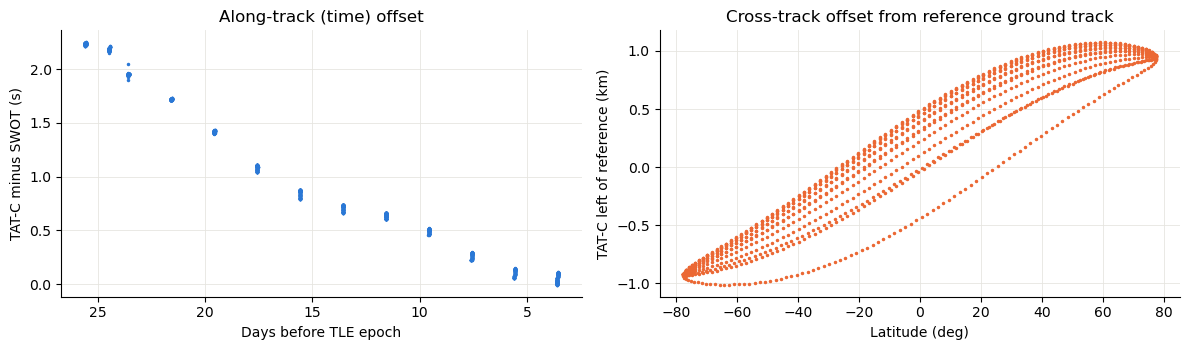

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].plot(offsets["days before TLE epoch"], offsets["along-track offset (s)"], ".", ms=3, color=BLUE)
axes[0].set(xlabel="Days before TLE epoch", ylabel="TAT-C minus SWOT (s)", title="Along-track (time) offset")
axes[0].invert_xaxis()
axes[1].plot(offsets["latitude"], offsets["cross-track offset (km)"], ".", ms=3, color=ORANGE)
axes[1].set(xlabel="Latitude (deg)", ylabel="TAT-C left of reference (km)", title="Cross-track offset from reference ground track")
fig.tight_layout()
plt.show()

TAT-C's ground track follows SWOT's to within 1.1 km across track over the 25 days before the TLE's epoch. The cross-track offset varies with latitude, from about 1 km to the right of the reference ground track at 78 deg south to 1 km to its left at 60 to 78 deg north, as it would for an inclination that differs by about 0.008 deg; this is within the accuracy of TLEs and of SWOT's maintenance of its ground track (about 1 km). Along track, TAT-C's satellite is ahead of SWOT by an amount that grows with the time before the TLE's epoch, from less than 0.1 s (0.6 km) 4 days before to 2.2 s (14 km) 25 days before, as the TLE's mean motion and drag term do not exactly match SWOT's orbit over this period.

SWOT's repeat cycle is measured from pass 566 in cycles 55 and 56: the time between the observations of the same grid lines. TAT-C detects the repeat cycle of the TLE's orbit (`get_repeat_cycle`), which it uses to repeat the observations of the first cycle in longer analyses. Without that shortcut, the ground track propagated by SGP4 shifts from one cycle to the next; this shift is measured by propagating the TLE over pass 566 of cycle 56 and one repeat cycle later.

In [4]:
first, second = (g for g in granules if g["pass"] == 566)
lines = np.arange(0, min(len(first["time"]), len(second["time"])), 500)
measured_cycle = pd.to_timedelta(np.median((second["time"][lines] - first["time"][lines]).total_seconds()), unit="s")
repeat_cycle = swot.get_repeat_cycle()
lines = lines[(lines > 0) & (lines < len(second["time"]) - 1)]
times = second["time"][lines].to_pydatetime()
now = wgs84.subpoint_of(swot.elements[0].to_skyfield().at(timescale.from_datetimes(times)))
later = wgs84.subpoint_of(swot.elements[0].to_skyfield().at(timescale.from_datetimes([t + repeat_cycle for t in times])))
heading = geod.inv(second["longitude"][lines, NADIR], second["latitude"][lines, NADIR], second["longitude"][lines + 1, NADIR], second["latitude"][lines + 1, NADIR])[0]
azimuth, _, shift = geod.inv(now.longitude.degrees, now.latitude.degrees, later.longitude.degrees, later.latitude.degrees)
along_shift = shift * np.cos(np.radians(azimuth - heading)) / 1e3
cross_shift = -shift * np.sin(np.radians(azimuth - heading)) / 1e3
pd.Series(
    {
        "SWOT repeat cycle (pass 566, cycles 55 to 56)": str(measured_cycle),
        "same grid in both cycles (max position difference, m)": float(np.nanmax(np.hypot(first["latitude"][lines] - second["latitude"][lines], first["longitude"][lines] - second["longitude"][lines])) * 111e3),
        "TAT-C repeat cycle (get_repeat_cycle)": str(repeat_cycle),
        "difference (s)": (repeat_cycle - measured_cycle).total_seconds(),
        "SGP4 ground track shift after one TAT-C repeat cycle, along track, median (km)": float(np.median(along_shift)),
        "SGP4 ground track shift after one TAT-C repeat cycle, across track, median (km)": float(np.median(cross_shift)),
        "SGP4 ground track shift after one TAT-C repeat cycle, across track, max |x| (km)": float(np.max(np.abs(cross_shift))),
    }
)

SWOT repeat cycle (pass 566, cycles 55 to 56)                                       20 days 20:45:02.793814912
same grid in both cycles (max position difference, m)                                                      0.0
TAT-C repeat cycle (get_repeat_cycle)                                                 20 days, 20:44:58.894690
difference (s)                                                                                       -3.899125
SGP4 ground track shift after one TAT-C repeat cycle, along track, median (km)                       -5.370911
SGP4 ground track shift after one TAT-C repeat cycle, across track, median (km)                       1.999681
SGP4 ground track shift after one TAT-C repeat cycle, across track, max |x| (km)                       2.79018
dtype: object

SWOT repeats pass 566 after 20 days, 20 hours, 45 minutes, and 3 s, over an identical grid. TAT-C's repeat cycle for the TLE's orbit is 3.9 s shorter (a relative difference of 2e-6). Propagated by SGP4 without the repeat-cycle shortcut, the ground track shifts after one repeat cycle by 5.4 km along track and 2.0 km (at most 2.8 km) across track, whereas SWOT's ground track is maintained to within about 1 km: for analyses longer than a repeat cycle, the shortcut (`repeat_cycle_for_observation_events`) represents SWOT's maintained orbit better than direct propagation.

## Test 2: Swath Geometry

KaRIn's swaths extend from 10 to 60 km on either side of the ground track. Each is modeled as a rectangular `PointedInstrument` whose cross-track field of view spans the off-nadir angles of these distances from SWOT's 890.5 km altitude (on a spherical Earth), rolled to the center of the swath: positive roll (to the left of the direction of motion) for the left swath and negative roll for the right swath. The along-track field of view (1 deg) is not tested, as observations are reported at the time the view sweeps over a point (by default in the Earth-fixed velocity frame, as SWOT, like a synthetic aperture radar, images in zero-Doppler geometry).

For three files, every 250th grid line is sampled across the full grid, and `collect_observations` is evaluated for each pixel and instrument within 2 minutes of the line's time. Only lines over the open ocean (with good-quality heights in at least 40 pixels) are kept.

In [5]:
ALTITUDE = 890.5e3


def off_nadir_angle(distance, altitude=ALTITUDE):
    """Off-nadir angle (deg) to a ground distance from nadir, on a spherical Earth."""
    theta = distance / EARTH_MEAN_RADIUS
    return np.degrees(np.arctan2(EARTH_MEAN_RADIUS * np.sin(theta), EARTH_MEAN_RADIUS + altitude - EARTH_MEAN_RADIUS * np.cos(theta)))


INNER, OUTER = 10e3, 60e3
inner_angle, outer_angle = off_nadir_angle(INNER), off_nadir_angle(OUTER)
karin = {
    side: PointedInstrument(
        name=f"KaRIn {side}",
        cross_track_field_of_view=outer_angle - inner_angle,
        along_track_field_of_view=1,
        roll_angle=sign * (inner_angle + outer_angle) / 2,
        is_rectangular=True,
    )
    for side, sign in [("left", 1), ("right", -1)]
}
satellite = Satellite(name="SWOT", orbit=swot, instruments=list(karin.values()))
pd.DataFrame({side: {"roll angle (deg)": i.roll_angle, "cross-track field of view (deg)": i.cross_track_field_of_view} for side, i in karin.items()}).T.round(3)

,roll angle (deg),cross-track field of view (deg)
left,2.248,3.21
right,-2.248,3.21


In [6]:
def signed_distance(granule, line):
    """Distance (km) of each pixel of a line from the ground track, positive to the left of the direction of motion."""
    lat, lon = granule["latitude"][line], granule["longitude"][line]
    heading = geod.inv(lon[NADIR], lat[NADIR], granule["longitude"][line + 1, NADIR], granule["latitude"][line + 1, NADIR])[0]
    azimuth, _, distance = geod.inv(np.full(69, lon[NADIR]), np.full(69, lat[NADIR]), lon, lat)
    return -np.sign(np.sin(np.radians(azimuth - heading))) * distance / 1e3


def observe_pixel(args):
    """TAT-C observations of a grid pixel by each instrument near its line's time."""
    granule, line, pixel = args
    point = Point(id=0, latitude=float(granule["latitude"][line, pixel]), longitude=float(granule["longitude"][line, pixel]))
    time = granule["time"][line].floor("us").to_pydatetime()
    row = {"file": granule["name"], "line": line, "pixel": pixel, "good": bool(granule["good"][line, pixel])}
    for index, side in enumerate(karin):
        obs = collect_observations(point, satellite, time - timedelta(minutes=2), time + timedelta(minutes=2), instrument_index=index)
        row[f"observed {side}"] = not obs.empty
        row[f"epoch difference {side} (s)"] = (obs.epoch.iloc[0] - granule["time"][line]).total_seconds() if not obs.empty else np.nan
    return row


tasks, distances = [], {}
for granule in granules[1:12:4]:
    for line in range(250, len(granule["time"]) - 250, 250):
        if granule["good"][line].sum() >= 40:
            distances[(granule["name"], line)] = signed_distance(granule, line)
            tasks += [(granule, line, pixel) for pixel in range(69)]
with concurrent.futures.ThreadPoolExecutor(8) as pool:
    pixels = pd.DataFrame(list(pool.map(observe_pixel, tasks)))
pixels["distance (km)"] = [distances[(f, l)][p] for f, l, p in zip(pixels.file, pixels.line, pixels.pixel)]
by_pixel = pixels.groupby("pixel").agg(
    **{
        "distance (km)": ("distance (km)", "median"),
        "good-quality (%)": ("good", "mean"),
        "TAT-C left (%)": ("observed left", "mean"),
        "TAT-C right (%)": ("observed right", "mean"),
    }
)
by_pixel[["good-quality (%)", "TAT-C left (%)", "TAT-C right (%)"]] *= 100
pd.Series({"files": len({t[0]["name"] for t in tasks}), "ocean lines": len(distances), "pixels": len(pixels)})

files             3
ocean lines      64
pixels         4416
dtype: int64

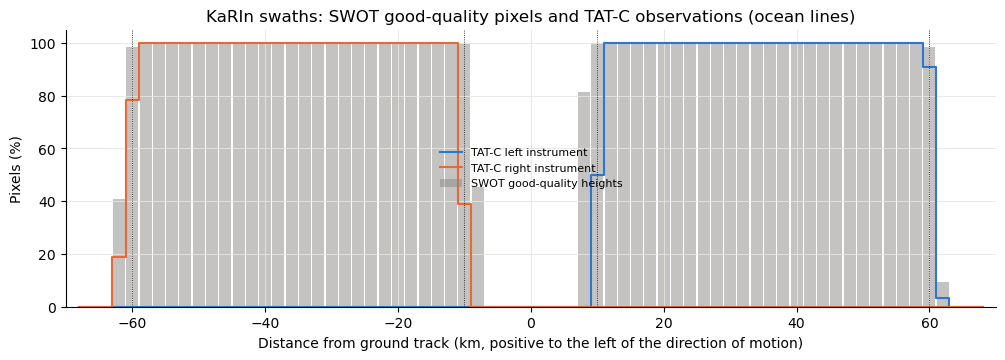

In [7]:
fig, ax = plt.subplots(figsize=(12, 3.6))
ax.bar(by_pixel["distance (km)"], by_pixel["good-quality (%)"], width=1.8, color=GRAY, alpha=0.5, label="SWOT good-quality heights")
ax.step(by_pixel["distance (km)"], by_pixel["TAT-C left (%)"], where="mid", color=BLUE, lw=1.5, label="TAT-C left instrument")
ax.step(by_pixel["distance (km)"], by_pixel["TAT-C right (%)"], where="mid", color=ORANGE, lw=1.5, label="TAT-C right instrument")
for edge in (-OUTER, -INNER, INNER, OUTER):
    ax.axvline(edge / 1e3, color=INK, lw=0.6, ls=":")
ax.set(xlabel="Distance from ground track (km, positive to the left of the direction of motion)", ylabel="Pixels (%)", title="KaRIn swaths: SWOT good-quality pixels and TAT-C observations (ocean lines)", xlim=(-70, 70))
ax.legend(frameon=False, fontsize=8, loc="center")
plt.show()

In [8]:
pixels["observed"] = pixels["observed left"] | pixels["observed right"]
pixels["epoch difference (s)"] = pixels["epoch difference left (s)"].fillna(pixels["epoch difference right (s)"])
inside = pixels["distance (km)"].abs().between(INNER / 1e3 + 1, OUTER / 1e3 - 1)
outside = (pixels["distance (km)"].abs() < INNER / 1e3 - 1) | (pixels["distance (km)"].abs() > OUTER / 1e3 + 1)
left = pixels["distance (km)"] > 0
corrected = pixels["epoch difference (s)"] + pixels.file.map(table1["along-track offset, median (s)"])
pd.Series(
    {
        "pixels 11 to 59 km from the ground track: good quality (%)": 100 * pixels.good[inside].mean(),
        "pixels 11 to 59 km from the ground track: observed by TAT-C (%)": 100 * pixels.observed[inside].mean(),
        "pixels 11 to 59 km from the ground track: observed by the instrument on their side (%)": 100 * np.mean(np.where(left[inside], pixels["observed left"][inside], pixels["observed right"][inside])),
        "pixels within 9 km or beyond 61 km: good quality (%)": 100 * pixels.good[outside].mean(),
        "pixels within 9 km or beyond 61 km: observed by TAT-C (%)": 100 * pixels.observed[outside].mean(),
        "good-quality pixels observed by TAT-C (%)": 100 * pixels.observed[pixels.good].mean(),
        "epoch minus line time, median (s)": pixels["epoch difference (s)"].median(),
        "epoch minus line time, p95 |x| (s)": pixels["epoch difference (s)"].abs().quantile(0.95),
        "epoch minus line time, corrected for the orbit's along-track offset (Test 1), median (s)": corrected.median(),
        "epoch minus line time, corrected for the orbit's along-track offset (Test 1), p95 |x| (s)": corrected.abs().quantile(0.95),
    }
).round(2)

pixels 11 to 59 km from the ground track: good quality (%)                                   100.00
pixels 11 to 59 km from the ground track: observed by TAT-C (%)                              100.00
pixels 11 to 59 km from the ground track: observed by the instrument on their side (%)       100.00
pixels within 9 km or beyond 61 km: good quality (%)                                          10.39
pixels within 9 km or beyond 61 km: observed by TAT-C (%)                                      1.29
good-quality pixels observed by TAT-C (%)                                                     94.50
epoch minus line time, median (s)                                                             -1.09
epoch minus line time, p95 |x| (s)                                                             2.19
epoch minus line time, corrected for the orbit's along-track offset (Test 1), median (s)       0.00
epoch minus line time, corrected for the orbit's along-track offset (Test 1), p95 |x| (s)      0.04


The rolled instruments reproduce KaRIn's swaths and the gap between them: every pixel 11 to 59 km from the ground track has good-quality heights over the ocean and is observed by TAT-C, always by the instrument on its side (the left instrument, with a positive roll angle, observes the swath to the left of the direction of motion). Pixels in the gap (within 9 km of the ground track) and beyond 61 km are not observed by TAT-C (1%, at the edges), but SWOT's good-quality heights extend 1 to 2 km beyond the nominal edges (to pixels centered 8 and 62 km from the ground track, which have good heights on 9 to 100% of lines), so that TAT-C observes 94.5% of the good-quality pixels; a swath from about 8 to 62 km would capture these.

TAT-C's observation epochs precede the times of the lines by 1.1 s (median), which is the along-track offset of its orbit (Test 1): corrected for it, the epochs agree with the line times to within 0.04 s (95th percentile), confirming that observations in the Earth-fixed velocity frame occur when the satellite passes abeam of each pixel, as in SWOT's zero-Doppler geometry.

## Summary

| Test | Result |
| --- | --- |
| 1. Orbit and repeat cycle | TLE ground track within 1.1 km of SWOT's across track and 0.1 to 2.2 s along track, 4 to 25 days before the TLE epoch; `get_repeat_cycle` within 3.9 s of SWOT's 20.86-day repeat cycle |
| 2. Swath geometry (`PointedInstrument` with roll) | all pixels 11 to 59 km from the ground track observed, by the instrument on their side; none in the gap; observation epochs within 0.04 s of line times (corrected for the orbit offset) |

**Orbit.** A TLE propagated by SGP4 follows SWOT's non-sun-synchronous orbit to within about 1 km across track and a few seconds along track over three weeks, and TAT-C identifies its 20.86-day repeat cycle to within seconds. Repeating the first cycle's observations models SWOT's maintained ground track better than propagating the TLE across cycles.

**Swath geometry.** Two `PointedInstrument`s rolled to either side of the ground track model a wide-swath instrument with a nadir gap: their swaths, sides, and observation times match KaRIn's. The measured swath extends about 2 km beyond the nominal 10 to 60 km on each side.